# Basic example of chatbot

In [1]:

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import MemorySaver   # It Store memory in RAM
import operator
from dotenv import load_dotenv

load_dotenv()


In [2]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages] # State update with new value and to overcome this, here we are using add_messages to add new message in a list.
    

In [3]:
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')


def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}



In [16]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)



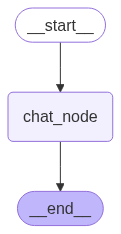

In [17]:
chatbot


In [6]:
# initial_state = {
#     'messages': [HumanMessage(content='What is the capital of india')]
# }

# chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is **New Delhi**.'

In [18]:
thread_id = '1'
while True:
    user_message = input('Ask here ')
    #print('User Message:', user_message)

    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    config = {'configurable': {'thread_id':thread_id }}
    response = chatbot.invoke({'messages' : [HumanMessage(content=user_message)]},config=config)
    print('AI: ',response['messages'][-1].content)


Ask here  HI my name is Suyash


AI:  Hi Suyash! It's nice to meet you. How can I help you today?


Ask here  what is my name?


AI:  Your name is Suyash. You just told me! 😊


Ask here  EXit


In [19]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='HI my name is Suyash', additional_kwargs={}, response_metadata={}, id='960c87de-9b30-41e1-9ac7-cf3bcd971e03'), AIMessage(content="Hi Suyash! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []}, id='run--c1ae4f87-69b7-42e4-bc23-e17e2d854920-0', usage_metadata={'input_tokens': 7, 'output_tokens': 19, 'total_tokens': 26, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='74874521-922f-46a9-badb-5291f69b192b'), AIMessage(content='Your name is Suyash. You just told me! 😊', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []}, id='run--2

In [ ]:
# Testing : Mix Example

In [23]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [48]:
class testState(TypedDict):
    val : int
    target : int
    result : int
    status : Literal['Pass','Fail']
    iteration : int
    max_iteration : int
    aa : int
    bb : int
    cc : int
    sumval : int

def Val_def(state : testState):
    a = state['val']
    # if state['iteration'] == 1:
    #     a = state['val']
    # else:
    #     a = state['sumval']
    return {'result': a}

def two(state : testState):
    b = state['result']*2
    return {'aa': b}

def three(state : testState):
    b = state['result']*3
    return {'bb': b}

def four(state : testState):
    b = state['result']*4
    return {'cc': b}

def check(state : testState):
    if  state['iteration'] == 1:
        d = state['aa']+state['bb']+state['cc']
    else:
        d = state['sumval']
    if d > state['target']:
        e = 'Pass'
    else:
        e = 'Fail'
    
    return {'sumval':d, 'status': e}

def optimize(state : testState):
    g = state['sumval']*2
    f = state['iteration']+1
    return {'sumval': g, 'iteration': f}

def check_condition(state : testState):
    if state['status'] == 'Pass' or state['iteration']>=state['max_iteration']:
        return 'End this'
    else:
        return 'Add on'

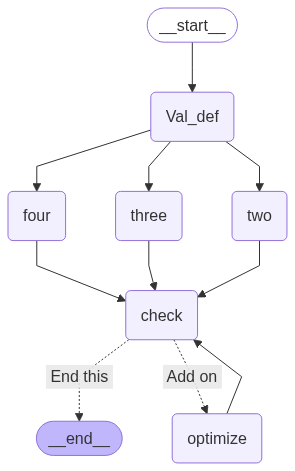

In [49]:
graph = StateGraph(testState)

graph.add_node('Val_def',Val_def)
graph.add_node('two',two)
graph.add_node('three',three)
graph.add_node('four',four)
graph.add_node('check',check)
graph.add_node('optimize',optimize)

graph.add_edge(START,'Val_def')
graph.add_edge('Val_def','two')
graph.add_edge('Val_def','three')
graph.add_edge('Val_def','four')

graph.add_edge('two','check')
graph.add_edge('three','check')
graph.add_edge('four','check')

graph.add_conditional_edges('check',check_condition,{'End this': END,'Add on':'optimize'})
graph.add_edge('optimize','check')

#graph.add_edge('check',END)

workflow = graph.compile()
workflow

In [53]:
initial = {

     'val' : 2,
    'iteration' : 1,
    'target' : 1000,
    'max_iteration' : 5
}

workflow.invoke(initial)['iteration']

5